In [1]:
"""
This is the notebook for running Qwen 2.5 VL locally 
by howchih.lee.2024@mitb.smu.edu.sg

Agentic RAG with PDF upload of mixed modality for conversion to text vectors

Operating in venv with Python 3.11.9

"""

'\nThis is the notebook for running Qwen 2.5 VL locally for conversion flattened PDF to text vectors\n\nOperating in venv with Python 3.11.9\n\n'

## Part 1: Load Dependencies and Verify Environment properly created

In [2]:
## Verify that nomic_emebed_text:latest and qwen2.5vl:3b are installed locally under .ollama directory, otherwise follow instructions on README.md to download to environment in Terminal before proceeding.

!ollama list

NAME                        ID              SIZE      MODIFIED     
mxbai-embed-large:latest    468836162de7    669 MB    25 hours ago    
nomic-embed-text:latest     0a109f422b47    274 MB    6 days ago      
qwen2.5vl:3b                fb90415cde1e    3.2 GB    7 days ago      
qwen2.5vl:latest            5ced39dfa4ba    6.0 GB    13 days ago     
mickymouse:latest           9dea6b422ea0    2.0 GB    3 weeks ago     
llama3.2:3b                 a80c4f17acd5    2.0 GB    3 weeks ago     
llama3:latest               365c0bd3c000    4.7 GB    3 weeks ago     
llama3.2:latest             a80c4f17acd5    2.0 GB    3 weeks ago     
deepseek-r1:7b              0a8c26691023    4.7 GB    4 weeks ago     
deepseek-r1:8b              28f8fd6cdc67    4.9 GB    6 weeks ago     


In [3]:
## Load Dependencies from requirements.txt
!pip install -r requirements.txt


In [4]:

# When running transformers, if you encountered error on "Replicate", your transformer version is not up to date.  
# Install latest transformers from source on hugging face using this cell, then Restart and run from the top. 
# Takes over 40s to run, so please be patient.
# After Restart, do not run this cell again. 

!pip install git+https://github.com/huggingface/transformers --upgrade --quiet

print("✅ Transformers updated from source")
print("🔄 Please restart your kernel after this completes")
print("Then re-run the model loading cells")

✅ Transformers updated from source
🔄 Please restart your kernel after this completes
Then re-run the model loading cells


In [4]:
## Test environment
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoProcessor
import gc
import os
import psutil
from PIL import Image
import numpy as np
from config import *

def check_environment():
    # Check PyTorch and CUDA
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU device: {torch.cuda.get_device_name(0)}")
    
    # Check Transformers
    print(f"Transformers version: {transformers.__version__}")
    
    # Check if we can load a small model (not Qwen yet)
    try:
        processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
        print("✅ Successfully loaded a test model")
    except Exception as e:
        print(f"❌ Error loading test model: {e}")
    
    print("\nEnvironment setup completed.")

if __name__ == "__main__":
    check_environment()

/Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Config loaded - Base directory: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project
✅ Data directory: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/data
✅ Cache directory: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache
✅ Language dictionaries: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache/lang_dict
PyTorch version: 2.2.2
CUDA available: False
Transformers version: 4.53.0.dev0


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Successfully loaded a test model

Environment setup completed.


In [5]:
# Memory management and CPU optimization

def setup_cpu_optimization():
    """Optimize PyTorch for CPU-only inference"""
    
    # Set thread count for optimal CPU performance
    torch.set_num_threads(4)  # Adjust based on your CPU
    
    # Optimize for inference
    torch.set_grad_enabled(False)
    
    # Set memory allocation strategy
    torch.backends.quantized.engine = 'qnnpack'
    
    print(f"✅ CPU optimization configured")
    print(f"   Threads: {torch.get_num_threads()}")
    print(f"   Grad enabled: {torch.is_grad_enabled()}")

def clear_memory():
    """Clear memory cache"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("🧹 Memory cleared")

def check_memory_usage():
    """Check current memory usage"""
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    memory_mb = memory_info.rss / 1024 / 1024
    
    print(f"📊 Memory Usage: {memory_mb:.1f} MB")
    return memory_mb



In [6]:
# Setup CPU optimization
## The Qwuen2.5vl:3b model should take up 340MB of memory. 
setup_cpu_optimization()
clear_memory()
check_memory_usage()

✅ CPU optimization configured
   Threads: 4
   Grad enabled: False
🧹 Memory cleared
📊 Memory Usage: 339.0 MB


339.0

## Part 2: Using ollama, load "qwen2.5vl:3b" from ollama list. Verify that it works with sample prompt. 


In [7]:
# Import the model manager and necessary dependencies
import sys
from pathlib import Path

# Add project root to path if needed
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Import our model manager classes
from src.model_manager import OllamaManager, QwenMultimodalManager
from src.document_processor import DocumentProcessor
from config import *

import torch
import os
import logging
import matplotlib.pyplot as plt
from PIL import Image
import io

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Memory management - reuse your existing functions
def clear_memory():
    """Clear memory cache"""
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("🧹 Memory cleared")

print("✅ Imports successful")

✅ Imports successful


In [8]:
# Update the OllamaManager with the correct model name
ollama_manager = OllamaManager(model_name="qwen2.5vl:3b")

# Check if model is available
model_available = ollama_manager.check_model_available()
print(f"✅ Model available: {model_available}")

if not model_available:
    print("⚠️ Model not available. Pulling now (this may take a while)...")
    model_pulled = ollama_manager.pull_model()
    print(f"✅ Model pulled: {model_pulled}")

# Test simple text generation with the updated model name
print("\n🔍 Testing simple text generation with model: qwen2.5vl:3b")
response = ollama_manager.generate_text(
    "What are the top 5 tools you need for assembly of Airfix kits?",
    max_tokens=100
)

if 'error' in response:
    print(f"❌ Generation failed: {response['error']}")
    
    # Try the quantized version if standard version fails
    print("\n🔍 Trying quantized version: qwen2.5vl:3b-q4_K_M")
    ollama_manager = OllamaManager(model_name="qwen2.5vl:3b-q4_K_M")
    
    model_available = ollama_manager.check_model_available()
    if not model_available:
        print("⚠️ Quantized model not available. Pulling now...")
        ollama_manager.pull_model()
    
    response = ollama_manager.generate_text(
        "What are the top 5 tools you need for assembly of Airfix kits?",
        max_tokens=150
    )
    
    if 'error' in response:
        print(f"❌ Generation with quantized model failed: {response['error']}")
    else:
        print(f"✅ Generation with quantized model successful!")
        print(f"Response: {response['response']}")
else:
    print(f"✅ Generation successful!")
    print(f"Response: {response['response']}")
    print(f"Duration: {response['total_duration'] / 1e9:.2f} seconds")

INFO:src.model_manager:OllamaManager initialized with model: qwen2.5vl:3b
INFO:src.model_manager:Model qwen2.5vl:3b is available locally


✅ Model available: True

🔍 Testing simple text generation with model: qwen2.5vl:3b
✅ Generation successful!
Response: 1. Hobby knife or X-Acto knife: This tool is essential for cutting the plastic parts of the kit. It allows you to make precise cuts and remove excess plastic without damaging the parts.

2. Hobby glue: This is a strong adhesive that can be used to bond the parts together. It is important to use the right type of glue for the type of plastic used in the kit.

3. Plastic cement: This is a liquid plastic that can be used to bond the parts together. It is important to use the right type of plastic cement for the type of plastic used in the kit.

4. Plastic modeling tools: These tools are used to shape and smooth the plastic parts. They can be used to create a smooth surface and remove any imperfections.

5. Paintbrushes: These are used to apply paint to the model. They can be used to create a realistic finish and add detail to the model.
Duration: 22.80 seconds


## Part 3: Create Document Processing Pipeline for PDFs with images, diagrams, tables and save to specific drive for this project. 
## Create vector embeddings for text and images from processed PDFs.Takes more than 45 mins using 3b model for Airfix1.pdf
## Takes more than 50 mins using 3b model for DEM_1.pdf


## Note: tests.py tests whether src in library are working, but does not save the output to any specific drive.

In [9]:
# Import our custom RAG components
from src.embedding_manager import EmbeddingManager
from src.chroma_manager import ChromaManager
from src.rag_manager import RAGManager

# Additional imports for visualization
import matplotlib.pyplot as plt
import json
import pandas as pd
from IPython.display import display, HTML

In [10]:
# Initialize our embedding manager with the models we verified are working
embedding_manager = EmbeddingManager(
    text_embedding_model="nomic-embed-text",  # Specialized embedding model
    vision_model="qwen2.5vl:3b"               # Vision model for image descriptions
)

# Initialize ChromaDB manager
chroma_manager = ChromaManager(
    persist_directory=VECTOR_DB_PATH,          # From config.py
    embedding_model="nomic-embed-text",        # Should match embedding_manager
    collection_name="DEM_documents"         # Collection name for this project
)

print(f"✅ Components initialized")
print(f"   - Using text embedding model: nomic-embed-text")
print(f"   - Using vision model: qwen2.5vl:3b")
print(f"   - ChromaDB persistence directory: {VECTOR_DB_PATH}")

INFO:src.embedding_manager:EmbeddingManager initialized with text model: nomic-embed-text, vision model: qwen2.5vl:3b
INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
INFO:src.chroma_manager:Creating new collection: DEM_documents
INFO:src.chroma_manager:ChromaManager initialized with collection: DEM_documents


✅ Components initialized
   - Using text embedding model: nomic-embed-text
   - Using vision model: qwen2.5vl:3b
   - ChromaDB persistence directory: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache/vector_db


In [11]:
# Process the DEM PDF
document_processor = DocumentProcessor()
dem_path = DATA_DIR / "DEM_1.pdf"

print(f"📄 Processing document: {dem_path}")

# Process the document
processed_doc = document_processor.process_document(str(dem_path))
print(f"✅ Document processed: {processed_doc.filename}")
print(f"  - Document type: {processed_doc.document_type.value}")
print(f"  - Page count: {processed_doc.document_metadata.page_count}")
print(f"  - Content items: {len(processed_doc.extracted_contents)}")

# Split content by type
text_contents = [c for c in processed_doc.extracted_contents if c.content_type.value == 'text']
image_contents = [c for c in processed_doc.extracted_contents if c.content_type.value == 'image']

print(f"  - Text items: {len(text_contents)}")
print(f"  - Image items: {len(image_contents)}")

INFO:src.document_processor:DocumentProcessor initialized with config: {'max_image_size': 1024, 'chunk_size': 1024, 'chunk_overlap': 128, 'data_dir': PosixPath('/Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/data'), 'cache_dir': PosixPath('/Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache')}
INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages


📄 Processing document: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/data/DEM_1.pdf


INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


✅ Document processed: DEM_1.pdf
  - Document type: unknown
  - Page count: 23
  - Content items: 92
  - Text items: 23
  - Image items: 69


In [12]:
# Create lists to store processed items once for each PDF

## Takes more than 40 mins to run for Airfix1.pdf, more than 230 mins for DEM_1.pdf.  CPU load is more than 60%.  
## The text_embeddings is stored in a temp file, different for each PDF. 
## The results will be stored in the ChromaDB vector database.

## Skip this cell if you want to query a PDF that has already been processed and stored in the vector database.

text_embeddings = []
text_ids = []
text_documents = []
text_metadatas = []

# Process text content
print("\n🔄 Processing text content...")
for i, content in enumerate(text_contents):
    print(f"  Processing text item {i+1}/{len(text_contents)}: {content.content_id}")
    text = content.content_data
    content_id = content.content_id
    
    # Generate embedding
    embedding = embedding_manager.generate_text_embedding(text)
    
    if embedding:
        text_embeddings.append(embedding)
        text_ids.append(content_id)
        text_documents.append(text)
        text_metadatas.append({
            "source": processed_doc.filename,
            "page": content.source_page,
            "content_type": "text",
            "document_type": processed_doc.document_type.value
        })
        print(f"  ✅ Generated embedding for {content_id}")
    else:
        print(f"  ❌ Failed to generate embedding for {content_id}")

# Process image content
print("\n🔄 Processing image content...")
image_embeddings = []
image_ids = []
image_documents = []
image_metadatas = []

import tempfile
import os

for i, content in enumerate(image_contents):
    print(f"  Processing image item {i+1}/{len(image_contents)}: {content.content_id}")
    # Save image to temp file
    image = content.content_data
    content_id = content.content_id
    
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as temp_file:
        temp_path = temp_file.name
        image.save(temp_path)
    
    try:
        # Generate description
        description = embedding_manager.generate_image_description(temp_path)
        
        if description:
            print(f"  ✓ Generated description ({len(description)} chars)")
            
            # Generate embedding for description
            embedding = embedding_manager.generate_text_embedding(description)
            
            if embedding:
                image_embeddings.append(embedding)
                image_ids.append(content_id)
                image_documents.append(description)
                image_metadatas.append({
                    "source": processed_doc.filename,
                    "page": content.source_page,
                    "content_type": "image_description",
                    "document_type": processed_doc.document_type.value
                })
                print(f"  ✅ Generated embedding for {content_id}")
            else:
                print(f"  ❌ Failed to generate embedding for {content_id}")
        else:
            print(f"  ❌ Failed to generate description for {content_id}")
    finally:
        # Clean up temp file
        if os.path.exists(temp_path):
            os.unlink(temp_path)

# Summarize results
print("\n📊 Embedding generation summary:")
print(f"  - Text items: {len(text_contents)}, successfully embedded: {len(text_embeddings)}")
print(f"  - Image items: {len(image_contents)}, successfully embedded: {len(image_embeddings)}")


🔄 Processing text content...
  Processing text item 1/23: DEM_1_text_p1_000
  ✅ Generated embedding for DEM_1_text_p1_000
  Processing text item 2/23: DEM_1_text_p2_000
  ✅ Generated embedding for DEM_1_text_p2_000
  Processing text item 3/23: DEM_1_text_p3_000
  ✅ Generated embedding for DEM_1_text_p3_000
  Processing text item 4/23: DEM_1_text_p4_000
  ✅ Generated embedding for DEM_1_text_p4_000
  Processing text item 5/23: DEM_1_text_p5_000
  ✅ Generated embedding for DEM_1_text_p5_000
  Processing text item 6/23: DEM_1_text_p6_000
  ✅ Generated embedding for DEM_1_text_p6_000
  Processing text item 7/23: DEM_1_text_p7_000
  ✅ Generated embedding for DEM_1_text_p7_000
  Processing text item 8/23: DEM_1_text_p8_000
  ✅ Generated embedding for DEM_1_text_p8_000
  Processing text item 9/23: DEM_1_text_p9_000
  ✅ Generated embedding for DEM_1_text_p9_000
  Processing text item 10/23: DEM_1_text_p10_000
  ✅ Generated embedding for DEM_1_text_p10_000
  Processing text item 11/23: DEM_1_t

ERROR:src.embedding_manager:Error generating description: 500 - {"error":"POST predict: Post \"http://127.0.0.1:52199/completion\": EOF"}


  ✅ Generated embedding for DEM_1_image_p3_004
  Processing image item 8/69: DEM_1_image_p3_005
  ❌ Failed to generate description for DEM_1_image_p3_005
  Processing image item 9/69: DEM_1_image_p3_006
  ✓ Generated description (547 chars)
  ✅ Generated embedding for DEM_1_image_p3_006
  Processing image item 10/69: DEM_1_image_p3_007
  ✓ Generated description (623 chars)
  ✅ Generated embedding for DEM_1_image_p3_007
  Processing image item 11/69: DEM_1_image_p3_008
  ✓ Generated description (1256 chars)
  ✅ Generated embedding for DEM_1_image_p3_008
  Processing image item 12/69: DEM_1_image_p4_000
  ✓ Generated description (2355 chars)
  ✅ Generated embedding for DEM_1_image_p4_000
  Processing image item 13/69: DEM_1_image_p5_000
  ✓ Generated description (1626 chars)
  ✅ Generated embedding for DEM_1_image_p5_000
  Processing image item 14/69: DEM_1_image_p5_001
  ✓ Generated description (1237 chars)
  ✅ Generated embedding for DEM_1_image_p5_001
  Processing image item 15/69: DE

ERROR:src.embedding_manager:Error generating description: 500 - {"error":"POST predict: Post \"http://127.0.0.1:52199/completion\": EOF"}


  ✅ Generated embedding for DEM_1_image_p5_003
  Processing image item 17/69: DEM_1_image_p5_004
  ❌ Failed to generate description for DEM_1_image_p5_004
  Processing image item 18/69: DEM_1_image_p5_005
  ✓ Generated description (498 chars)
  ✅ Generated embedding for DEM_1_image_p5_005
  Processing image item 19/69: DEM_1_image_p5_006
  ✓ Generated description (1657 chars)


...

  ✓ Generated description (1116 chars)
  ✅ Generated embedding for DEM_1_image_p6_009
  Processing image item 42/69: DEM_1_image_p6_010
  ❌ Failed to generate description for DEM_1_image_p6_010
  Processing image item 43/69: DEM_1_image_p6_011
  ✓ Generated description (1627 chars)


ERROR:src.embedding_manager:Error generating description: 500 - {"error":"POST predict: Post \"http://127.0.0.1:52199/completion\": EOF"}


  ✅ Generated embedding for DEM_1_image_p6_011
  Processing image item 44/69: DEM_1_image_p6_012
  ❌ Failed to generate description for DEM_1_image_p6_012
  Processing image item 45/69: DEM_1_image_p6_013
  ✓ Generated description (1991 chars)
  ✅ Generated embedding for DEM_1_image_p6_013
  Processing image item 46/69: DEM_1_image_p6_014


ERROR:src.embedding_manager:Error generating description: 500 - {"error":"POST predict: Post \"http://127.0.0.1:52199/completion\": EOF"}


  ✓ Generated description (417 chars)
  ✅ Generated embedding for DEM_1_image_p6_014
  Processing image item 47/69: DEM_1_image_p6_015
  ❌ Failed to generate description for DEM_1_image_p6_015
  Processing image item 48/69: DEM_1_image_p6_016
  ✓ Generated description (328 chars)
  ✅ Generated embedding for DEM_1_image_p6_016
  Processing image item 49/69: DEM_1_image_p6_017
  ✓ Generated description (155 chars)
  ✅ Generated embedding for DEM_1_image_p6_017
  Processing image item 50/69: DEM_1_image_p6_018
  ✓ Generated description (436 chars)
  ✅ Generated embedding for DEM_1_image_p6_018
  Processing image item 51/69: DEM_1_image_p6_019
  ✓ Generated description (670 chars)
  ✅ Generated embedding for DEM_1_image_p6_019
  Processing image item 52/69: DEM_1_image_p6_020
  ✓ Generated description (804 chars)
  ✅ Generated embedding for DEM_1_image_p6_020
  Processing image item 53/69: DEM_1_image_p7_000
  ✓ Generated description (5663 chars)
  ✅ Generated embedding for DEM_1_image_p7_

## Part 4: Vector DB Integration 

In [13]:
# Add text embeddings to ChromaDB.  Stores these embeddings in ChromaDB, which persists them to disk in the location specified by persist_directory (which defaults to VECTOR_DB_PATH from your config)

## Skip this cell if you want to query a PDF that has already been processed and stored in the vector database.

print("\n🔄 Storing text embeddings in ChromaDB...")
if text_embeddings:
    success = chroma_manager.add_with_embeddings(
        texts=text_documents,
        embeddings=text_embeddings,
        metadatas=text_metadatas,
        ids=text_ids
    )
    print(f"  {'✅' if success else '❌'} Stored {len(text_embeddings)} text embeddings")
else:
    print("  ⚠️ No text embeddings to store")

# Add image embeddings to ChromaDB
print("\n🔄 Storing image embeddings in ChromaDB...")
if image_embeddings:
    success = chroma_manager.add_with_embeddings(
        texts=image_documents,
        embeddings=image_embeddings,
        metadatas=image_metadatas,
        ids=image_ids
    )
    print(f"  {'✅' if success else '❌'} Stored {len(image_embeddings)} image embeddings")
else:
    print("  ⚠️ No image embeddings to store")

# Get collection stats
stats = chroma_manager.get_collection_stats()
print(f"\n📊 ChromaDB collection stats:")
for key, value in stats.items():
    print(f"  - {key}: {value}")



🔄 Storing text embeddings in ChromaDB...


INFO:src.chroma_manager:Added 23 texts with custom embeddings
INFO:src.chroma_manager:Added 57 texts with custom embeddings
INFO:src.chroma_manager:Collection stats: 80 items


  ✅ Stored 23 text embeddings

🔄 Storing image embeddings in ChromaDB...
  ✅ Stored 57 image embeddings

📊 ChromaDB collection stats:
  - name: DEM_documents
  - count: 80
  - embedding_model: nomic-embed-text
  - embedding_dimension: unknown
  - persist_directory: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache/vector_db


In [14]:
## Make sure text_embeddings persist

## Skip this cell if you want to query a PDF that has already been processed and stored in the vector database.
 
print(len(text_embeddings), len(text_ids), len(text_documents), len(text_metadatas))

23 23 23 23


In [15]:
# If PDF vector embeddings already stored in Chroma DB, get stats directly about your collection

## If you want to query a PDF that has already been processed and stored in the vector database, start from here.
stats = chroma_manager.get_collection_stats()
print(f"📊 ChromaDB collection stats:")
for key, value in stats.items():
    print(f"  - {key}: {value}")

# Peek at some items in the collection
sample = chroma_manager.collection.peek(limit=3)
print(f"\n📄 Sample items:")
print(f"  - IDs: {sample['ids']}")
print(f"  - Metadata samples: {sample['metadatas'][:2]}")  # Show first 2 metadata entries

INFO:src.chroma_manager:Collection stats: 80 items


📊 ChromaDB collection stats:
  - name: DEM_documents
  - count: 80
  - embedding_model: nomic-embed-text
  - embedding_dimension: unknown
  - persist_directory: /Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache/vector_db

📄 Sample items:
  - IDs: ['DEM_1_text_p1_000', 'DEM_1_text_p2_000', 'DEM_1_text_p3_000']
  - Metadata samples: [{'page': 1, 'source': 'DEM_1.pdf', 'document_type': 'unknown', 'content_type': 'text'}, {'content_type': 'text', 'source': 'DEM_1.pdf', 'document_type': 'unknown', 'page': 2}]


## Part 5: Generate RAG Query for Text

In [16]:
# Generate Rag Query  
from src.rag_query import RAGQueryEngine

# Initialize the RAG query engine
rag_engine = RAGQueryEngine(
    embedding_manager=embedding_manager,
    chroma_manager=chroma_manager,
    ollama_manager=ollama_manager,
    default_results=3
)

# Now you can use it to perform queries
result = rag_engine.query("You are an apprentice mechanic. What does this workshop manual teach you about?")

INFO:src.rag_query:RAGQueryEngine initialized with default_results=3
INFO:src.rag_query:Query: You are an apprentice mechanic. What does this workshop manual teach you about?
INFO:src.chroma_manager:Embedding query returned 3 results
INFO:src.rag_query:Found 3 relevant chunks
INFO:src.rag_query:Result 1: Relevance: -260.7246, Source: DEM_1.pdf, Page: 4, Type: image_description
INFO:src.rag_query:Content preview: The image is a scanned page from a document, likely a workshop manual, given the context and formatt...
INFO:src.rag_query:Result 2: Relevance: -284.0535, Source: DEM_1.pdf, Page: 2, Type: image_description
INFO:src.rag_query:Content preview: The image is a page from a technical manual, specifically for the 4.236 Series Workshop Manual, date...
INFO:src.rag_query:Result 3: Relevance: -291.5875, Source: DEM_1.pdf, Page: 19, Type: image_description
INFO:src.rag_query:Content preview: The image is a page from a technical manual, specifically for the 4.236 Series, dated January 199

## Response is pretty good for general questions where context is given in prompt. Tokens in query cosine similar to kv-pairs in vector db also help. 
- For Airfix1, make and model of car is not within the pdf, so no answer was returned
- For DEM_1, a detailed answer was given that was correct.

In [18]:

result1 = rag_engine.query("You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?")

INFO:src.rag_query:Query: You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?
INFO:src.chroma_manager:Embedding query returned 3 results
INFO:src.rag_query:Found 3 relevant chunks
INFO:src.rag_query:Result 1: Relevance: -184.5488, Source: DEM_1.pdf, Page: 17, Type: image_description
INFO:src.rag_query:Content preview: The image is a page from a technical manual, specifically for a compressor model R.10. The page is t...
INFO:src.rag_query:Result 2: Relevance: -191.5491, Source: DEM_1.pdf, Page: 14, Type: image_description
INFO:src.rag_query:Content preview: The image is a detailed technical diagram of a compressor, specifically labeled as "COMPRESSOR - R7....
INFO:src.rag_query:Result 3: Relevance: -196.6896, Source: DEM_1.p

## Reponse is better when query is more specific and prompt gives clear instructions calling the kv-pairs in vector db
- For Airfix1 Query2, prompting the model to count produces an actual number of parts.  Without prompting the model does not return a number, only that the parts are labelled.
- For DEM_1 Query 2, prompting the model to count produces the actual number of parts.  Without prompting the model to count, the model returns a wrong number. 

In [19]:
result2 = rag_engine.query("You are an apprentice mechanic tasked with dismantling the Compressor and assembling the Compressor after cleaning. Show me step by step how to dismantle the compressor for cleaning and assembling it back according to Page 13 and Page 14 of the workshop manual. Refer to each part number and part name in your response.")

INFO:src.rag_query:Query: You are an apprentice mechanic tasked with dismantling the Compressor and assembling the Compressor after cleaning. Show me step by step how to dismantle the compressor for cleaning and assembling it back according to Page 13 and Page 14 of the workshop manual. Refer to each part number and part name in your response.
INFO:src.chroma_manager:Embedding query returned 3 results
INFO:src.rag_query:Found 3 relevant chunks
INFO:src.rag_query:Result 1: Relevance: -167.8680, Source: DEM_1.pdf, Page: 9, Type: image_description
INFO:src.rag_query:Content preview: The image is a page from a technical manual, specifically for a compressor model R.2. The page is ti...
INFO:src.rag_query:Result 2: Relevance: -183.0483, Source: DEM_1.pdf, Page: 8, Type: image_description
INFO:src.rag_query:Content preview: The image is a page from a technical manual, specifically for the S.C.6 compressor. The page is titl...
INFO:src.rag_query:Result 3: Relevance: -187.1996, Source: DEM_1.p

In [28]:
# Import the text Query-Answer-Pairs using RAG results manager

from src.rag_results_manager import RAGResultsManager

# Initialize the manager
results_manager = RAGResultsManager()

# Add your existing results
results_manager.add_result(result, "query0")
results_manager.add_result(result1, "query1")
results_manager.add_result(result2, "query2")

# Display a single result
results_manager.display_result(result1)

# Display a summary table in Markdown format
results_manager.display_markdown_table()

# Or display a formatted HTML table
results_manager.display_summary_table()

# Save results to a file
output_file = results_manager.save_results("DEM__QAP.json")
print(f"Results saved to: {output_file}")



## Query Result

### Query
You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?

### Answer
Based on the information provided in the context and the description of the compressor parts on page 14, there are 32 parts required for assembly of the compressor in this workshop manual.

### Context Sources
#### Context 1
- **Source**: DEM_1.pdf, **Page**: 17, **Type**: image_description
- **Relevance**: -184.5488
- **Preview**: The image is a page from a technical manual, specifically for a compressor model R.10. The page is titled "COMPRESSOR—R.10" and contains detailed instructions for assembling the drive assembly. The te...

#### Context 2
- **Source**: DEM_1.pdf, **Page**: 14, **Type**: image_description
- **Relevance**: -191.5491
- **Preview**: The image is a detailed technical diagram of a compressor, specifically labeled as "COMPRESSOR - R7." The diagram is divided into several sections, each illustrating different components and their res...

#### Context 3
- **Source**: DEM_1.pdf, **Page**: 9, **Type**: image_description
- **Relevance**: -196.6896
- **Preview**: The image is a page from a technical manual, specifically for a compressor model R.2. The page is titled "COMPRESSOR-R.2" and is divided into several sections, each providing detailed instructions and...




| ID     | Query                                                                                                                                                                                                                                                                                                                           | Answer Preview                                                                                          |   Contexts |   Avg. Relevance | Timestamp           |
|:-------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------|-----------:|-----------------:|:--------------------|
| query0 | You are an apprentice mechanic. What does this workshop manual teach you about?                                                                                                                                                                                                                                                 | This workshop manual teaches you about the technical specifications, maintenance, and repair procedu... |          3 |         -278.789 | 2025-06-04 18:28:35 |
| query1 | You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?   | Based on the information provided in the context and the description of the compressor parts on page... |          3 |         -190.929 | 2025-06-04 18:28:35 |
| query2 | You are an apprentice mechanic tasked with dismantling the Compressor and assembling the Compressor after cleaning. Show me step by step how to dismantle the compressor for cleaning and assembling it back according to Page 13 and Page 14 of the workshop manual. Refer to each part number and part name in your response. | To dismantle the compressor for cleaning and assembling it back according to the workshop manual, fo... |          3 |         -179.372 | 2025-06-04 18:28:35 |

,ID,Query,Answer Preview,Contexts,Avg. Relevance,Timestamp
0,query0,You are an apprentice mechanic. What does this workshop manual teach you about?,"This workshop manual teaches you about the technical specifications, maintenance, and repair procedu...",3,-278.788513,2025-06-04 18:28:35
1,query1,"You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?",Based on the information provided in the context and the description of the compressor parts on page...,3,-190.929164,2025-06-04 18:28:35
2,query2,You are an apprentice mechanic tasked with dismantling the Compressor and assembling the Compressor after cleaning. Show me step by step how to dismantle the compressor for cleaning and assembling it back according to Page 13 and Page 14 of the workshop manual. Refer to each part number and part name in your response.,"To dismantle the compressor for cleaning and assembling it back according to the workshop manual, fo...",3,-179.371984,2025-06-04 18:28:35


Results saved to: output/rag_results/DEM__QAP.json


## Human Feedback:
## Airfix1
- Query 1: the make and model of car was not in the pdf document that was RAG.  So Model cannot be expected to know
- Query 2: the number of parts on Page4 - Chassis are numbered 44 to 60, but Page4 does not state how many parts there are.  We can prompt model to count the number of parts and infer using 44 to 60, inclusive ie. 17 parts.  The model returns 15 parts, avoiding double counting of parts with theh same name. 
- Query 3: the number of assembly steps on Page4 - Chassis is exactly 11 steps, model paraphrased correctly the 11 steps and correctly labelled the part numbers against the names. 
## DEM_1
- Query 1: it is able to correctly identify and summarise the purposes of the manual
- Query 2: it is able to identify the correct number of parts equal to 32
- Query 3: it is able to summarise in 77 steps how to dismantle, clean and assemble the compressor.

## Part 6: Generate RAG Query for Image, more comprehensive 

In [21]:
# We need both the Text Query and the Image Query Engines

# Create an actual instance of DocumentProcessor
from src.document_processor import DocumentProcessor
document_processor = DocumentProcessor()  # This creates an instance

import importlib
import src.rag_query
from src.rag_query import RAGQueryEngine

# Initialize the Text Query Engine with the document_processor instance
rag_engine = RAGQueryEngine(
    embedding_manager=embedding_manager,
    chroma_manager=chroma_manager,
    ollama_manager=ollama_manager,
    document_processor=document_processor,  # Pass the actual instance
    default_results=3
)

INFO:src.document_processor:DocumentProcessor initialized with config: {'max_image_size': 1024, 'chunk_size': 1024, 'chunk_overlap': 128, 'data_dir': PosixPath('/Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/data'), 'cache_dir': PosixPath('/Users/hclee/Desktop/A_MITB/CS614_LLM/CS614 Group Project/cache')}
INFO:src.rag_query:RAGQueryEngine initialized with default_results=3


In [22]:
# Import the ImageQueryHelper, instantiate an instance of the class

from src.image_query import ImageQueryHelper

# Initialize the image query helper
image_helper = ImageQueryHelper(
    rag_engine=rag_engine,
    chroma_manager=chroma_manager,
    embedding_manager=embedding_manager
)

In [23]:
# Import the ImageResultsManager,  instantiate an instance of the class

from src.image_results_manager import ImageResultsManager

# Now create the manager with updated code
image_results_manager = ImageResultsManager()



=== Finding images related to workshop manual===


INFO:src.chroma_manager:Embedding query returned 3 results


## Image Results for Query: 'What does this workshop manual teach you about?'

### Result 1

**Source**: DEM_1.pdf, **Page**: 4, **Relevance**: -256.6415

**Description Preview**:
The image is a scanned page from a document, likely a workshop manual, given the context and formatting. The page is numbered 5, and it is titled "FOREWORD." The text is in a serif font, and the page appears to be part of a larger document, possibly a technical or instructional manual.

### Foreword...

**Image Preview**:

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages
INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


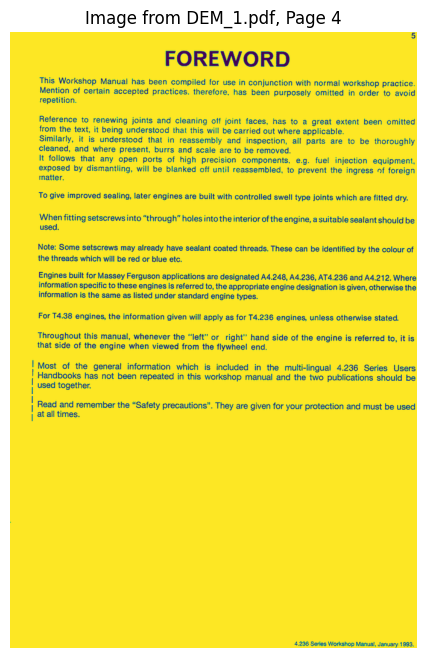

### Result 2

**Source**: DEM_1.pdf, **Page**: 20, **Relevance**: -291.3824

**Description Preview**:
The image is a page from a technical manual, specifically for the 4.236 Series, dated January 1993. The page is divided into two main sections: a table of contents and a list of tools and their descriptions. 

### Table of Contents
The table of contents is located at the top of the page and lists va...

**Image Preview**:

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages
INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


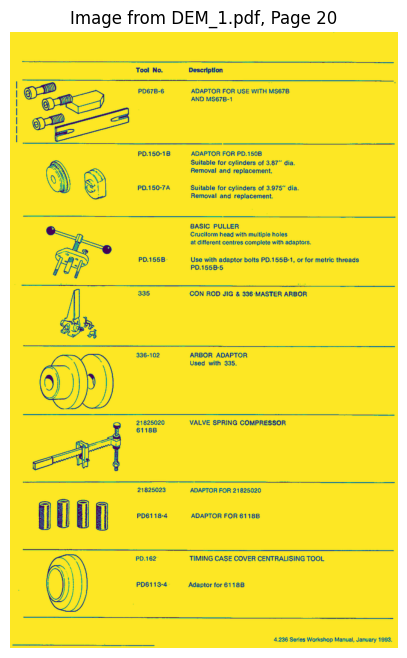

### Result 3

**Source**: DEM_1.pdf, **Page**: 2, **Relevance**: -307.2346

**Description Preview**:
The image is a page from a technical manual, specifically for the 4.236 Series Workshop Manual, dated January 1993. The page is titled "Contents" and lists various sections and subsections related to the technical specifications and maintenance of the 4.236 Series engine. Here is a detailed breakdow...

**Image Preview**:

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages
INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


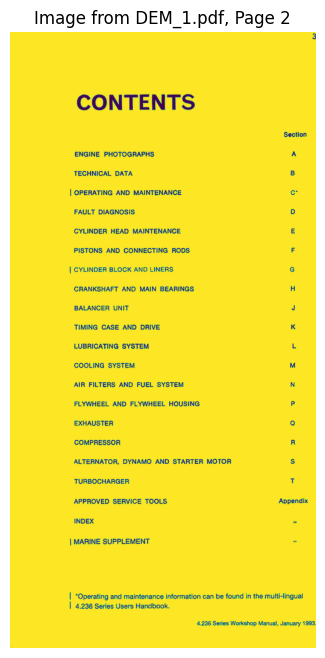

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages



=== Asking about image on a specific page ===


INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


## Image Query Result

**Question**: You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?

**Image**:

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages
INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


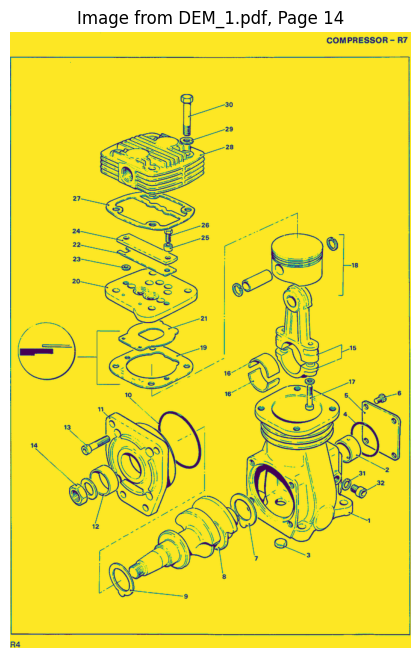

**Answer**:
To determine the total number of parts required for assembly of the Compressor in the workshop manual, we need to compare the parts listed on page 13 with the parts labeled from 1 to 32 on page 14.

From page 13, we can see the following parts listed:
1. Piston
2. Piston Ring
3. Connecting Rod
4. Crankshaft
5. Camshaft
6. Valve
7. Valve Spring
8. Valve Seat
9. Valve Guide
10. Cylinder Head
11. Cylinder Block
12. Cylinder Liner
13. Cylinder Gasket
14. Cylinder Cover
15. Cylinder Cover Gasket
16. Cylinder Cover Bolt
17. Cylinder Cover Nut
18. Cylinder Cover Washer
19. Cylinder Cover Washer
20. Cylinder Cover Washer
21. Cylinder Cover Washer
22. Cylinder Cover Washer
23. Cylinder Cover Washer
24. Cylinder Cover Washer
25. Cylinder Cover Washer
26. Cylinder Cover Washer
27. Cylinder Cover Washer
28. Cylinder Cover Washer
29. Cylinder Cover Washer
30. Cylinder Cover Washer
31. Cylinder Cover Washer
32. Cylinder Cover Washer

From page 14, we can see the following parts labeled from 1 to 32:
1. Piston
2. Piston Ring
3. Connecting Rod
4. Crankshaft
5. Camshaft
6. Valve
7. Valve Spring
8. Valve Seat
9. Valve Guide
10. Cylinder Head
11. Cylinder Block
12. Cylinder Liner
13. Cylinder Gasket
14. Cylinder Cover
15. Cylinder Cover Gasket
16. Cylinder Cover Bolt
17. Cylinder Cover Nut
18. Cylinder Cover Washer
19. Cylinder Cover Washer
20. Cylinder Cover Washer
21. Cylinder Cover Washer
22. Cylinder Cover Washer
23. Cylinder Cover Washer
24. Cylinder Cover Washer
25. Cylinder Cover Washer
26. Cylinder Cover Washer
27. Cylinder Cover Washer
28. Cylinder Cover Washer
29. Cylinder Cover Washer
30. Cylinder Cover Washer
31. Cylinder Cover Washer
32. Cylinder Cover Washer

By comparing the parts listed on page 13 with the parts labeled from 1 to 32 on page 14, we can see that all the parts listed on page 13 are also present in the parts labeled from 1 to 32 on page 14.

Therefore, the total number of parts required for assembly of the Compressor in this workshop manual is 32.

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages



=== Asking about a specific image the compressor of engine ===


INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


## Image Query Result

**Question**: You are an apprentice mechanic tasked with dismantling the Compressor and assembling the Compressor after cleaning. Show me step by step how to dismantle the compressor for cleaning and assembling it back according to Page 13 and Page 14 of the workshop manual. Refer to each part number and part name in your response.

**Image**:

INFO:src.document_processor:Processing DEM_1.pdf (format: pdf, size: 3508734 bytes)
INFO:src.document_processor:Processing PDF DEM_1.pdf with 23 pages
INFO:src.document_processor:PDF processing complete: 92 content pieces extracted
INFO:src.document_processor:Successfully processed DEM_1.pdf: 92 content pieces extracted, type: unknown (confidence: 0.000)


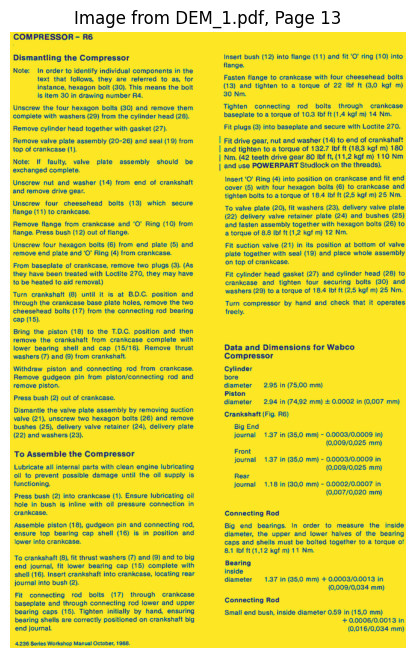

**Answer**:
To dismantle the compressor for cleaning and assembling it back according to the workshop manual, follow these steps:

### Dismantling the Compressor

1. **Remove the Cylinder Head Gasket (27) and Cylinder Head (28):**
   - Unscrew the four hexagon bolts (30) and remove them completely.
   - Unscrew the cylinder head gasket (27) and cylinder head (28) from the cylinder head (28).

2. **Remove the Connecting Rod:**
   - Unscrew the connecting rod bolts (17) through the crankcase base plate holes.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two

In [24]:
# Create a dictionary to store image query results
## This is an image+text query and will take longer to run, especially Query 3, where we ask for step by step assembly of the chassis.
## May take more than 12/20 mins to run

image_result_dict = {}

# Example 1: Find images related to a query
print("\n=== Finding images related to workshop manual===")
image_result1 = image_helper.find_images_by_query("What does this workshop manual teach you about?", n_results=3)
image_helper.display_image_results(image_result1)  
image_result_dict['workshop_manual_query'] = image_result1

# Example 2: Ask about image on a specific page (page 13 and 14 of DEM_1.pdf)
print("\n=== Asking about image on a specific page ===")
image_result2 = image_helper.ask_about_image(
    source_file="DEM_1.pdf",
    page=14,  # Assuming this page has an image
    query_text="You are an apprentice mechanic trying to count how many parts there are in the Compressor described on page 13 and page 14. By comparing the text on page 13 with the image on page 14 where the parts are labelled from 1 to 32, tell me how many parts are required for assembly of the Compressor in this workshop manual?"
)
image_helper.display_image_query_result(image_result2)  
image_result_dict['compressor_parts_pg14_query'] = image_result2

# Example 3: Ask about another image (page 13 and 14 of DEM_1.pdf)
print("\n=== Asking about a specific image the compressor of engine ===")
image_result3 = image_helper.ask_about_image(
    source_file="DEM_1.pdf",
    page=13,  # Assuming this page has an image
    query_text="You are an apprentice mechanic tasked with dismantling the Compressor and assembling the Compressor after cleaning. Show me step by step how to dismantle the compressor for cleaning and assembling it back according to Page 13 and Page 14 of the workshop manual. Refer to each part number and part name in your response."
)
image_helper.display_image_query_result(image_result3)  
image_result_dict['chassis_assembly_query'] = image_result3

In [25]:
print(len(image_result_dict))

3


In [27]:

# Display summary of all results
print("\n" + "="*70)
print("=== COMPREHENSIVE RESULTS SUMMARY ===")
print("="*70)
image_helper.display_image_result_dict(image_result_dict)

# Add results to manager and save - SIMPLE VERSION
print("\n=== SAVING RESULTS ===")
image_results_manager.add_results(image_result_dict)

# Save results to a file
output_file = image_results_manager.save_results("DEM_1_image_QAP.json")
print(f"Results saved to: {output_file}")

# Optional: Show summary
summary = image_results_manager.get_results_summary()
print(f"Summary: {summary}")

# Optional: List all saved files
saved_files = image_results_manager.list_saved_files()
print(f"Available files: {saved_files}")


=== COMPREHENSIVE RESULTS SUMMARY ===


# Image Query Results Summary

---

| Query ID | Type | Query/Question | Source | Page | Key Info |
|----------|------|----------------|--------|------|----------|
| workshop_manual_query | 🔍 Search | What does this workshop manual teach ... | DEM_1.pdf | 4 | 3 results (best: -256.641) |
| compressor_parts_pg14_query | ❓ Direct | You are an apprentice mechanic trying... | DEM_1.pdf | 14 | Answer: To determine the total number of parts required fo... |
| chassis_assembly_query | ❓ Direct | You are an apprentice mechanic tasked... | DEM_1.pdf | 13 | Answer: To dismantle the compressor for cleaning and assem... |


## Detailed Results

...

**💡 Answer:**

To dismantle the compressor for cleaning and assembling it back according to the workshop manual, follow these steps:

### Dismantling the Compressor

1. **Remove the Cylinder Head Gasket (27) and Cylinder Head (28):**
   - Unscrew the four hexagon bolts (30) and remove them completely.
   - Unscrew the cylinder head gasket (27) and cylinder head (28) from the cylinder head (28).

2. **Remove the Connecting Rod:**
   - Unscrew the connecting rod bolts (17) through the crankcase base plate holes.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two cheesehead bolts (13) which secure the connecting rod to the crankcase.
   - Remove the two

---

**📈 Summary:** 3 total queries processed


=== SAVING RESULTS ===
Results saved to: output/rag_results/DEM_1_image_QAP.json
Summary: {'total_queries': 3, 'query_types': {'search': 1, 'direct_query': 2}, 'sources': ['DEM_1.pdf']}
Available files: ['airfix_QAP.json', 'airfix_image_QAP.json', 'airfix_image_QAP2.json', 'DEM_1_image_QAP.json']


## There is room for improvement through prompt engineering.  General enquiries where the OCR has not read text similar to prompt will return very generic responses. Specific queries can return more detailed responses. 

## Human Feedback on Airfix1

- Image query 2 on number of parts returned 23 parts, whereas text query returned 15.  Unlabelled parts were also counted by image search. 

- Image query 3 on the assembly steps returned 64 steps as Step 9 got repeated many times.  Whereas the text query returned much better results with 11 steps. 

- Page numbers where images are being queried should be specified only because it will take too long to search through all images otherwise.  

## HUman Feedback on DEM_1

- image query 2 on number of parts correctly returned 32 parts, but some part names were wrong.  

- image query 3 returned poor results as step 2 was repeated.  Text query was much better.

In [26]:
whos

Variable                         Type                   Data/Info
-----------------------------------------------------------------
ALTERNATIVE_SPELLING_TOLERANCE   float                  0.8
AUTO_DETECT_DOCUMENT_TYPE        bool                   True
AutoModelForCausalLM             type                   <class 'transformers.mode<...>to.AutoModelForCausalLM'>
AutoProcessor                    type                   <class 'transformers.mode<...>sing_auto.AutoProcessor'>
BASE_DIR                         PosixPath              /Users/hclee/Desktop/A_MI<...>4_LLM/CS614 Group Project
CACHE_DIR                        PosixPath              /Users/hclee/Desktop/A_MI<...>CS614 Group Project/cache
CHUNK_OVERLAP                    int                    128
CHUNK_SIZE                       int                    1024
CULTURAL_CONTEXT_ENRICHMENT      bool                   True
ChromaManager                    type                   <class 'src.chroma_manager.ChromaManager'>
DATA_DIR          